In [1]:
import os
import pandas as pd
import re
from google.colab import drive

In [2]:
def parse_classification_report(text, folder_path):
    """
    Parses sklearn text classification report into a dataframe.
    """

    # Take only the classification table area
    report_text = text.split("Classification Report:")[1].strip()

    lines = report_text.split("\n")

    data = []

    # skip header lines until actual data begins
    for line in lines:
        # stop at empty line
        if not line.strip():
            continue
        # skip header lines
        if "precision" in line and "recall" in line:
            continue

        # Use regex to split on variable whitespace
        parts = re.split(r"\s{2,}", line.strip())

        # Expected formats:
        # label | precision | recall | f1 | support
        if len(parts) == 5:
            label, precision, recall, f1, support = parts
            data.append([folder_path, label, float(precision), float(recall), float(f1), int(support)])

        # Format for accuracy line: "accuracy 0.79 105853"
        elif parts[0] == "accuracy":
            label = "accuracy"
            # precision column is accuracy, recall column is "", f1/support parsed
            data.append([folder_path, "accuracy", float(parts[1]), None, None, int(parts[2])])

        # Format for macro avg / weighted avg
        elif parts[0] in ["macro avg", "weighted avg"]:
            label = parts[0]
            precision, recall, f1, support = parts[1:]
            data.append([folder_path, label, float(precision), float(recall), float(f1), int(support)])

    df = pd.DataFrame(data, columns=["folder", "label", "precision", "recall", "f1", "support"])
    return df

In [5]:
drive.mount('/content/drive')

base_folder = "/content/drive/Shared drives/Gestió de Projectes/Projecte/saved_model"

evaluation_rows = []
class_rows = []


# ========== MAIN LOOP ==========

for root, dirs, files in os.walk(base_folder):
    for file in files:
        if file == "evaluation.txt":
            eval_path = os.path.join(root, file)

            with open(eval_path, "r") as f:
                text = f.read()

            # extract accuracy
            acc = None
            for line in text.splitlines():
                if "Test Accuracy" in line:
                    acc = float(line.split(":")[1])

            evaluation_rows.append({"folder": root, "accuracy": acc})

            # parse classification table
            df_report = parse_classification_report(text, root)
            class_rows.append(df_report)



df_accuracy = pd.DataFrame(evaluation_rows)
df_classes = pd.concat(class_rows, ignore_index=True)

df_accuracy, df_classes


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(                                               folder  accuracy
 0   /content/drive/Shared drives/Gestió de Project...  0.850554
 1   /content/drive/Shared drives/Gestió de Project...  0.875650
 2   /content/drive/Shared drives/Gestió de Project...  0.857624
 3   /content/drive/Shared drives/Gestió de Project...  0.803976
 4   /content/drive/Shared drives/Gestió de Project...  0.743102
 5   /content/drive/Shared drives/Gestió de Project...  0.852740
 6   /content/drive/Shared drives/Gestió de Project...  0.877287
 7   /content/drive/Shared drives/Gestió de Project...  1.000000
 8   /content/drive/Shared drives/Gestió de Project...  0.818675
 9   /content/drive/Shared drives/Gestió de Project...  0.759107
 10  /content/drive/Shared drives/Gestió de Project...  0.781316
 11  /content/drive/Shared drives/Gestió de Project...  0.731272
 12  /content/drive/Shared drives/Gestió de Project...  0.869434
 13  /content/drive/Shared drives/Gestió de Project...  0.726738
 14  /content/drive/Share

In [20]:
# -----------------------------------------------
# 1. GLOBAL ACCURACY SUMMARY
# -----------------------------------------------
global_accuracy_mean = df_accuracy["accuracy"].mean()
global_accuracy_min = df_accuracy["accuracy"].min()
global_accuracy_max = df_accuracy["accuracy"].max()

df_global_accuracy = pd.DataFrame({
    "metric": ["mean", "min", "max"],
    "accuracy": [global_accuracy_mean, global_accuracy_min, global_accuracy_max]
})

print("===== GLOBAL ACCURACY =====")
display(df_global_accuracy)


# ---------------------------------------------------
# 2.  SUPPORT-WEIGHTED “TRUE GLOBAL” METRICS
# ---------------------------------------------------
df_classes_clean = df_classes[df_classes.label.isin(["accuracy"]) == False].copy()

df_support_sum = df_classes_clean.groupby("label")["support"].sum()

df_support_weighted = (
    df_classes_clean
    .assign(weight=lambda d: d["support"] / d.groupby("label")["support"].transform("sum"))
    .assign(weighted_precision=lambda d: d["precision"] * d["weight"])
    .assign(weighted_recall   =lambda d: d["recall"]    * d["weight"])
    .assign(weighted_f1       =lambda d: d["f1"]        * d["weight"])
    .groupby("label")[["weighted_precision", "weighted_recall", "weighted_f1"]]
    .sum()
)

df_support_weighted.columns = ["precision", "recall", "f1"]

print("===== SUPPORT-WEIGHTED TRUE GLOBAL METRICS =====")
display(df_support_weighted)


===== GLOBAL ACCURACY =====


,metric,accuracy
0,mean,0.837334
1,min,0.724091
2,max,1.000000


===== SUPPORT-WEIGHTED TRUE GLOBAL METRICS =====


,precision,recall,f1
label,,,
0,1.000000,1.000000,1.000000
1050752,0.630588,0.630588,0.630588
1052800,0.890465,0.828875,0.843924
131072,1.000000,0.800130,0.866753
131328,0.000000,0.000000,0.000000
133120,1.000000,1.000000,1.000000
16,1.000000,1.000000,1.000000
163840,0.825294,0.905351,0.860897
164096,0.693929,0.517426,0.568414


In [19]:
df_support_weighted_v2 = df_support_weighted[~df_support_weighted.index.isin(["macro avg", "weighted avg"])]
display(df_support_weighted_v2)


metrics = ["precision", "recall", "f1"]
results = []

for metric in metrics:
    min_value = df_support_weighted_v2[metric].min()
    min_label = df_support_weighted_v2[metric].idxmin()
    max_value = df_support_weighted_v2[metric].max()
    max_label = df_support_weighted_v2[metric].idxmax()
    macro_avg_value = df_support_weighted_v2[metric].mean()

    results.append({
        "metric": metric,
        "min_value": min_value,
        "min_label": min_label,
        "max_value": max_value,
        "max_label": max_label,
        "macro_avg": macro_avg_value
    })

df_min_max = pd.DataFrame(results)
print("\n===== MIN/MAX PER METRIC AND LABEL =====")
display(df_min_max)

,precision,recall,f1
label,,,
0,1.000000,1.000000,1.000000
1050752,0.630588,0.630588,0.630588
1052800,0.890465,0.828875,0.843924
131072,1.000000,0.800130,0.866753
131328,0.000000,0.000000,0.000000
133120,1.000000,1.000000,1.000000
16,1.000000,1.000000,1.000000
163840,0.825294,0.905351,0.860897
164096,0.693929,0.517426,0.568414



===== MIN/MAX PER METRIC AND LABEL =====


,metric,min_value,min_label,max_value,max_label,macro_avg
0,precision,0.0,131328,1.0,0,0.744217
1,recall,0.0,131328,1.0,0,0.702871
2,f1,0.0,131328,1.0,0,0.713630


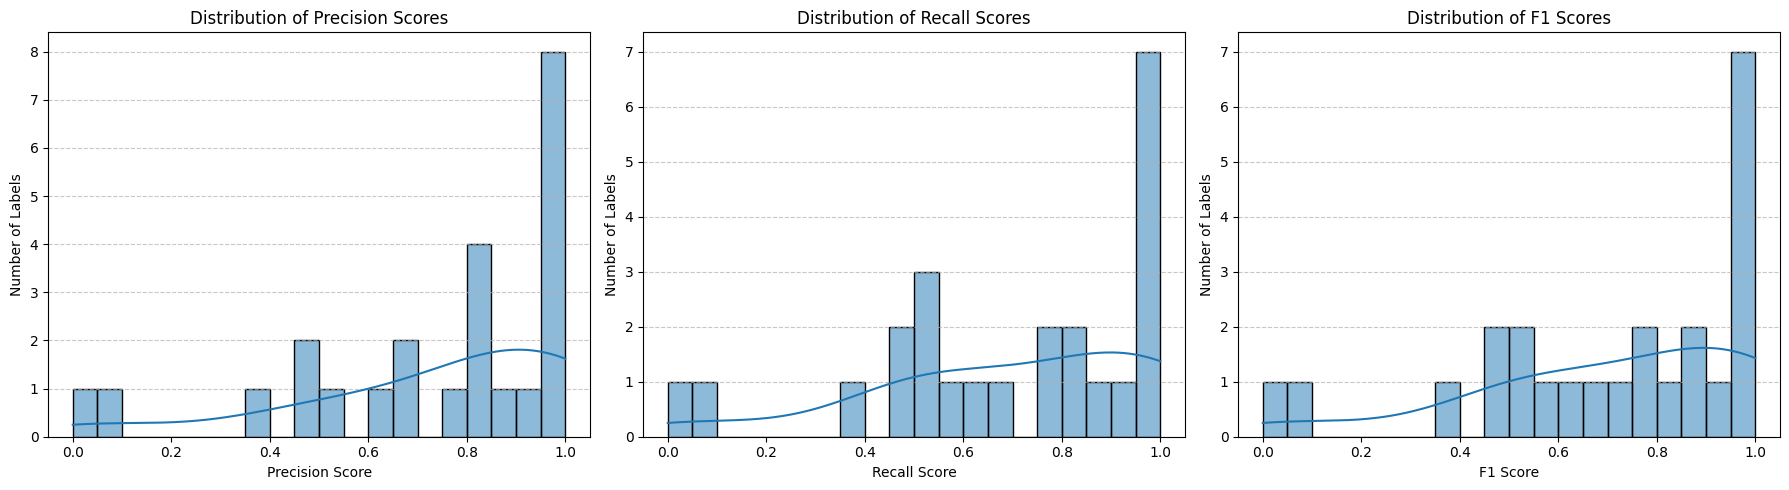

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["precision", "recall", "f1"]

plt.figure(figsize=(18, 5))

for i, metric in enumerate(metrics):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df_support_weighted_v2[metric], bins=20, kde=True)
    plt.title(f'Distribution of {metric.capitalize()} Scores')
    plt.xlabel(f'{metric.capitalize()} Score')
    plt.ylabel('Number of Labels')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()